Import the library

In [181]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import tracemalloc
import gc
import warnings

from typing import Dict
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold, train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.base import clone

Set global styles

In [182]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['legend.fontsize'] = 10

RANDOM_STATE = 42
W_XGBOOST = 0.0075
W_LIGHTGBM = 0.2325
W_CATBOOST = 0.7600
ALPHA_PROBABILITY = 0.8125
DECISION_THRESHOLD = 0.5050
N_SPLITS = 5

warnings.filterwarnings('ignore', category=UserWarning, module='lightgbm')

Convert the Boolean list to integer

In [183]:
def parse_bool_series(s: pd.Series) -> pd.Series:
    if s.dtype == bool:
        return s.astype(int)
    parsed = s.astype(str).str.lower().map({
        "true": 1, "false": 0, "1": 1, "0": 0, "yes": 1, "no": 0
    })
    if parsed.isna().any():
        raise ValueError("Cannot parse boolean values")
    return parsed.astype(int)

Load the dataset

In [184]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
PassengerId = test["PassengerId"]
y_train_raw = parse_bool_series(train["Transported"])

print(f"Shape of training set: {train.shape}")
print(f"Shape of test set: {test.shape}")
print(f"The first 5 examples of the training set:{train.head()}")

Shape of training set: (8693, 14)
Shape of test set: (4277, 13)
The first 5 examples of the training set:  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0     0.0    Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0       Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0      Altark Susent   
3          0.0     1283.0         371.0  3329.0   193.0       Solam Susent   
4        303.0       70.0         151.0   565.0     2.0  Willy Santantines   


Quick exploration

In [185]:
print("Describe:\n")
print(train.describe())
print("\nInfo:\n")
print(train.info())

Describe:

               Age   RoomService     FoodCourt  ShoppingMall           Spa  \
count  8514.000000   8512.000000   8510.000000   8485.000000   8510.000000   
mean     28.827930    224.687617    458.077203    173.729169    311.138778   
std      14.489021    666.717663   1611.489240    604.696458   1136.705535   
min       0.000000      0.000000      0.000000      0.000000      0.000000   
25%      19.000000      0.000000      0.000000      0.000000      0.000000   
50%      27.000000      0.000000      0.000000      0.000000      0.000000   
75%      38.000000     47.000000     76.000000     27.000000     59.000000   
max      79.000000  14327.000000  29813.000000  23492.000000  22408.000000   

             VRDeck  
count   8505.000000  
mean     304.854791  
std     1145.717189  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%       46.000000  
max    24133.000000  

Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data c

Data distributions

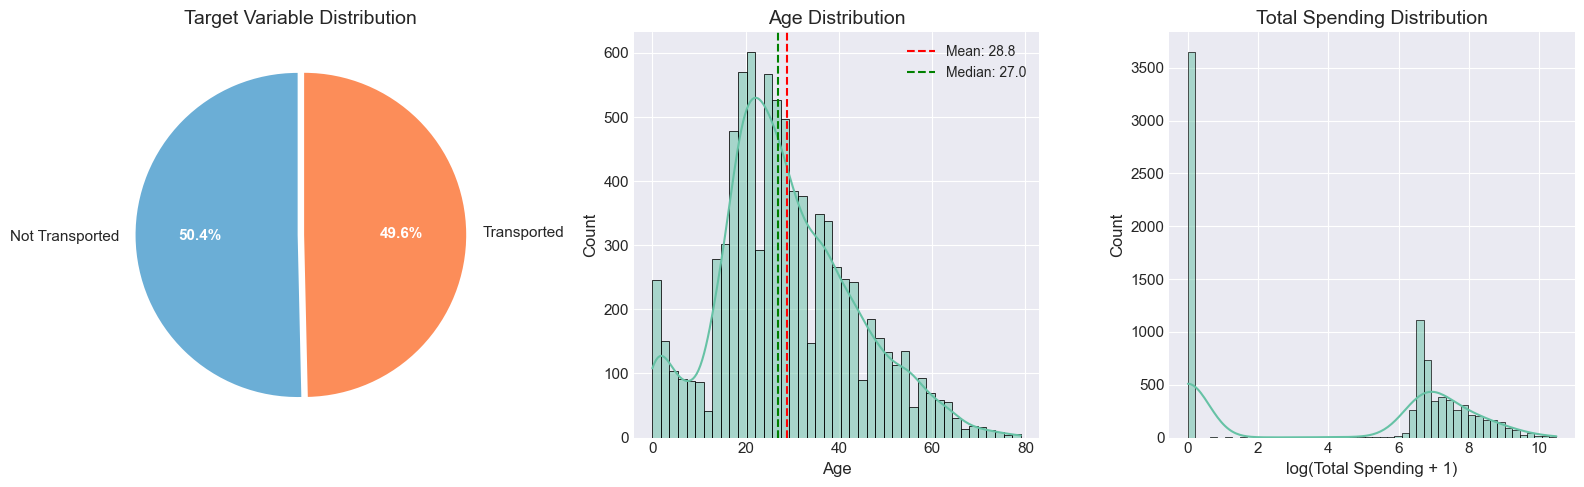

In [186]:
fig, axes = plt.subplots(1, 3, figsize = (16, 5))

colors = ['#6BAED6', '#FC8D59']
counts = train['Transported'].value_counts()
wedges, texts, autotexts = axes[0].pie(counts, labels=['Not Transported', 'Transported'], 
                                         autopct='%1.1f%%', colors=colors, startangle=90,
                                         explode=(0.02, 0.02))
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
axes[0].set_title('Target Variable Distribution')

sns.histplot(data=train, x='Age', kde=True, ax=axes[1])
axes[1].axvline(train['Age'].mean(), color='red', linestyle='--', label=f'Mean: {train["Age"].mean():.1f}')
axes[1].axvline(train['Age'].median(), color='green', linestyle='--', label=f'Median: {train["Age"].median():.1f}')
axes[1].set_title('Age Distribution')
axes[1].set_xlabel('Age')
axes[1].legend()

spending_sum = train[['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']].sum(axis=1)
sns.histplot(np.log1p(spending_sum), bins=50, kde=True, ax=axes[2])
axes[2].set_title('Total Spending Distribution')
axes[2].set_xlabel('log(Total Spending + 1)')

plt.tight_layout()
plt.show()

Categorical variable analysis

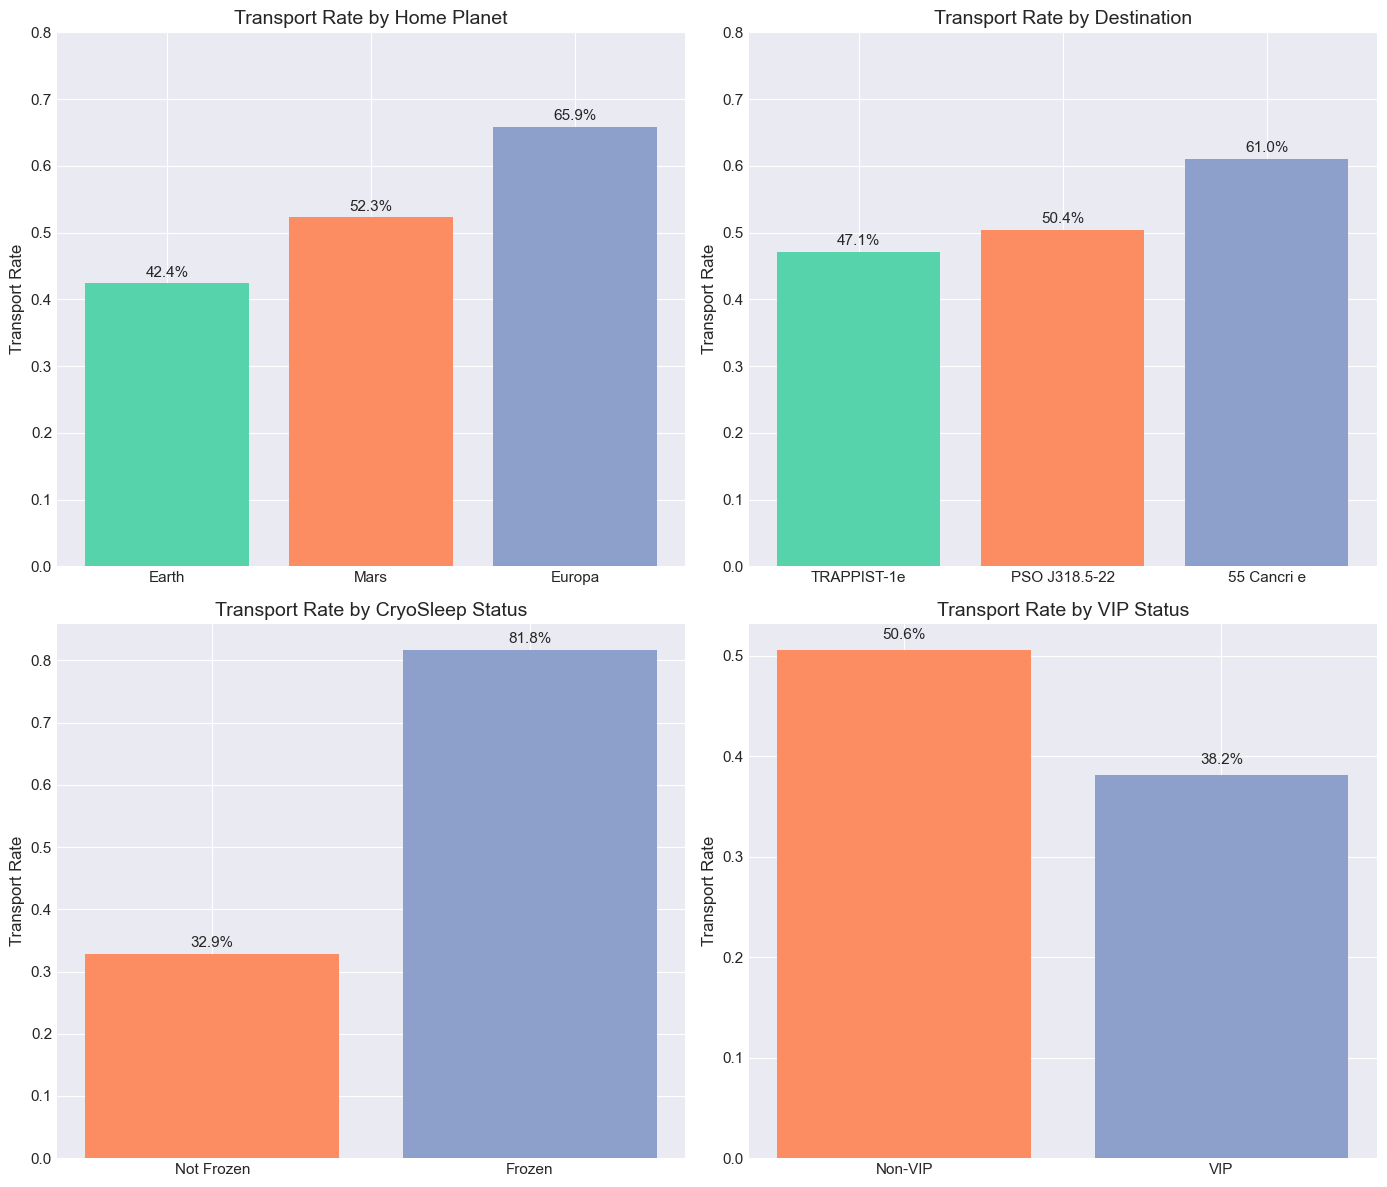

In [187]:
fig, axes = plt.subplots(2, 2, figsize = (14, 12))

homeplanet_tra = train.groupby('HomePlanet')['Transported'].mean().sort_values()
bars1 = axes[0,0].bar(homeplanet_tra.index, homeplanet_tra.values, color=['#57D3AC', '#FC8D62', '#8DA0CB'])
axes[0,0].set_title('Transport Rate by Home Planet')
axes[0,0].set_ylabel('Transport Rate')
axes[0,0].set_ylim(0, 0.8)
for bar, val in zip(bars1, homeplanet_tra.values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.1%}', ha='center')

dest_tra = train.groupby('Destination')['Transported'].mean().sort_values()
bars2 = axes[0,1].bar(dest_tra.index, dest_tra.values, color=['#57D3AC', '#FC8D62', '#8DA0CB'])
axes[0,1].set_title('Transport Rate by Destination')
axes[0,1].set_ylabel('Transport Rate')
axes[0,1].set_ylim(0, 0.8)
for bar, val in zip(bars2, dest_tra.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.1%}', ha='center')

cryo_data = train.groupby('CryoSleep')['Transported'].mean()
bars3 = axes[1,0].bar(['Not Frozen', 'Frozen'], cryo_data.values, color=['#FC8D62', '#8DA0CB'])
axes[1,0].set_title('Transport Rate by CryoSleep Status')
axes[1,0].set_ylabel('Transport Rate')
for bar, val in zip(bars3, cryo_data.values):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.1%}', ha='center')

vip_data = train.groupby('VIP')['Transported'].mean()
bars4 = axes[1,1].bar(['Non-VIP', 'VIP'], vip_data.values, color=['#FC8D62', '#8DA0CB'])
axes[1,1].set_title('Transport Rate by VIP Status')
axes[1,1].set_ylabel('Transport Rate')
for bar, val in zip(bars4, vip_data.values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.1%}', ha='center')

plt.tight_layout()
plt.show()

Missing value heatmap

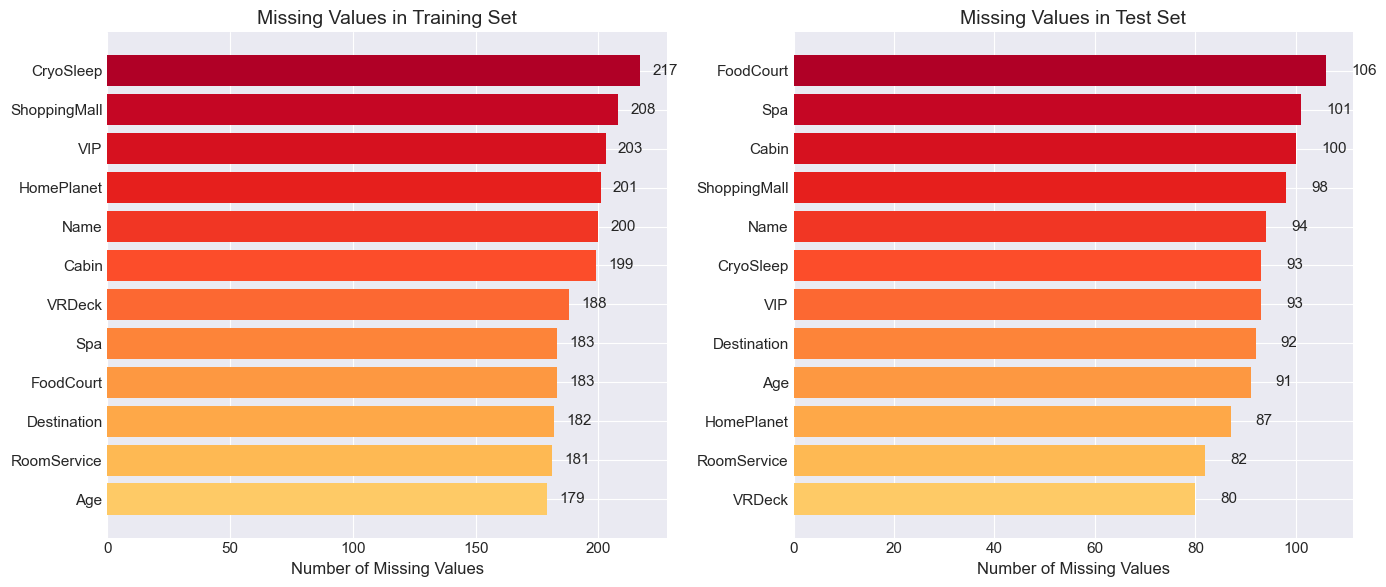

In [188]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

missing_train = train.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=True)
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(missing_train)))
bars1 = axes[0].barh(missing_train.index, missing_train.values, color=colors)
axes[0].set_title('Missing Values in Training Set')
axes[0].set_xlabel('Number of Missing Values')
for bar, val in zip(bars1, missing_train.values):
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, str(val), va='center')

missing_test = test.isnull().sum()
missing_test = missing_test[missing_test > 0].sort_values(ascending=True)
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(missing_test)))
bars2 = axes[1].barh(missing_test.index, missing_test.values, color=colors)
axes[1].set_title('Missing Values in Test Set')
axes[1].set_xlabel('Number of Missing Values')
for bar, val in zip(bars2, missing_test.values):
    axes[1].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, str(val), va='center')

plt.tight_layout()
plt.show()

Spending characteristic relationship

C:\Users\admin\AppData\Local\Temp\ipykernel_19292\337488144.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(spending_transported, labels=['Not Transported', 'Transported'], patch_artist=True, showmeans=True)


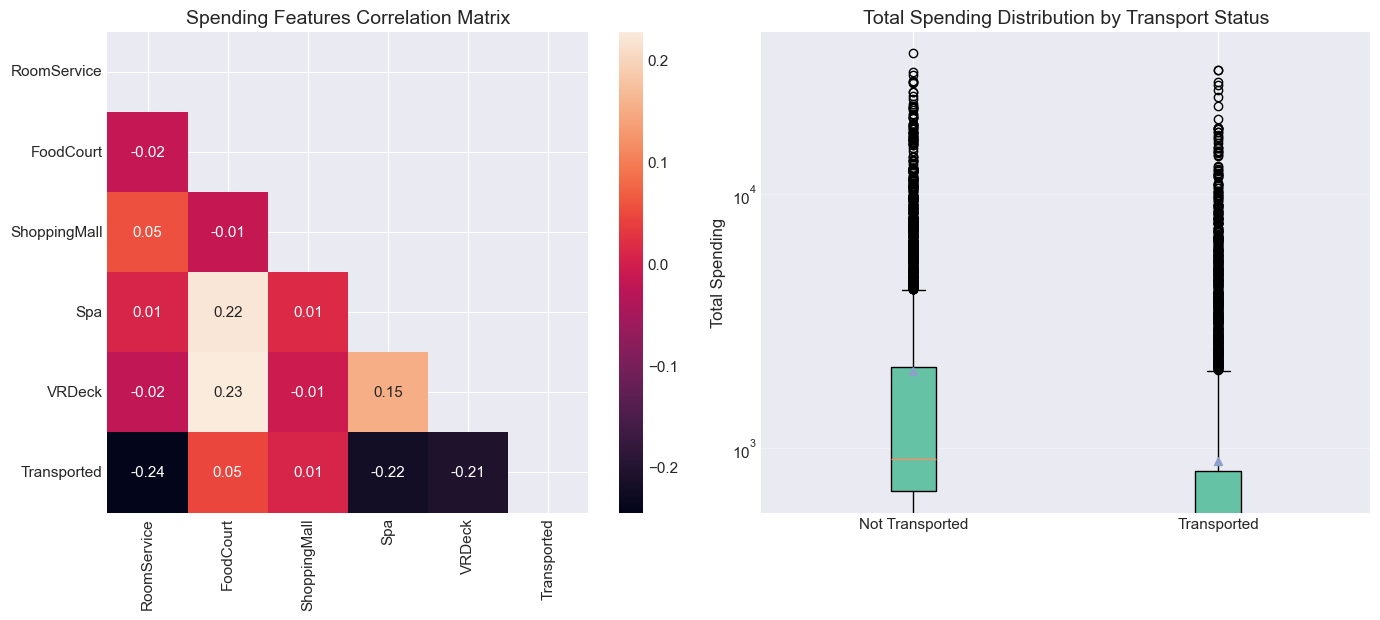

In [189]:
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

corr_matrix = train[spend_cols + ['Transported']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', square=True, ax=axes[0])
axes[0].set_title('Spending Features Correlation Matrix')

spending_sum = train[spend_cols].sum(axis=1)
spending_transported = [spending_sum[train['Transported'] == False], spending_sum[train['Transported'] == True]]
bp = axes[1].boxplot(spending_transported, labels=['Not Transported', 'Transported'], patch_artist=True, showmeans=True)

axes[1].set_title('Total Spending Distribution by Transport Status')
axes[1].set_ylabel('Total Spending')
axes[1].set_yscale('log')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Spending characteristics distribution

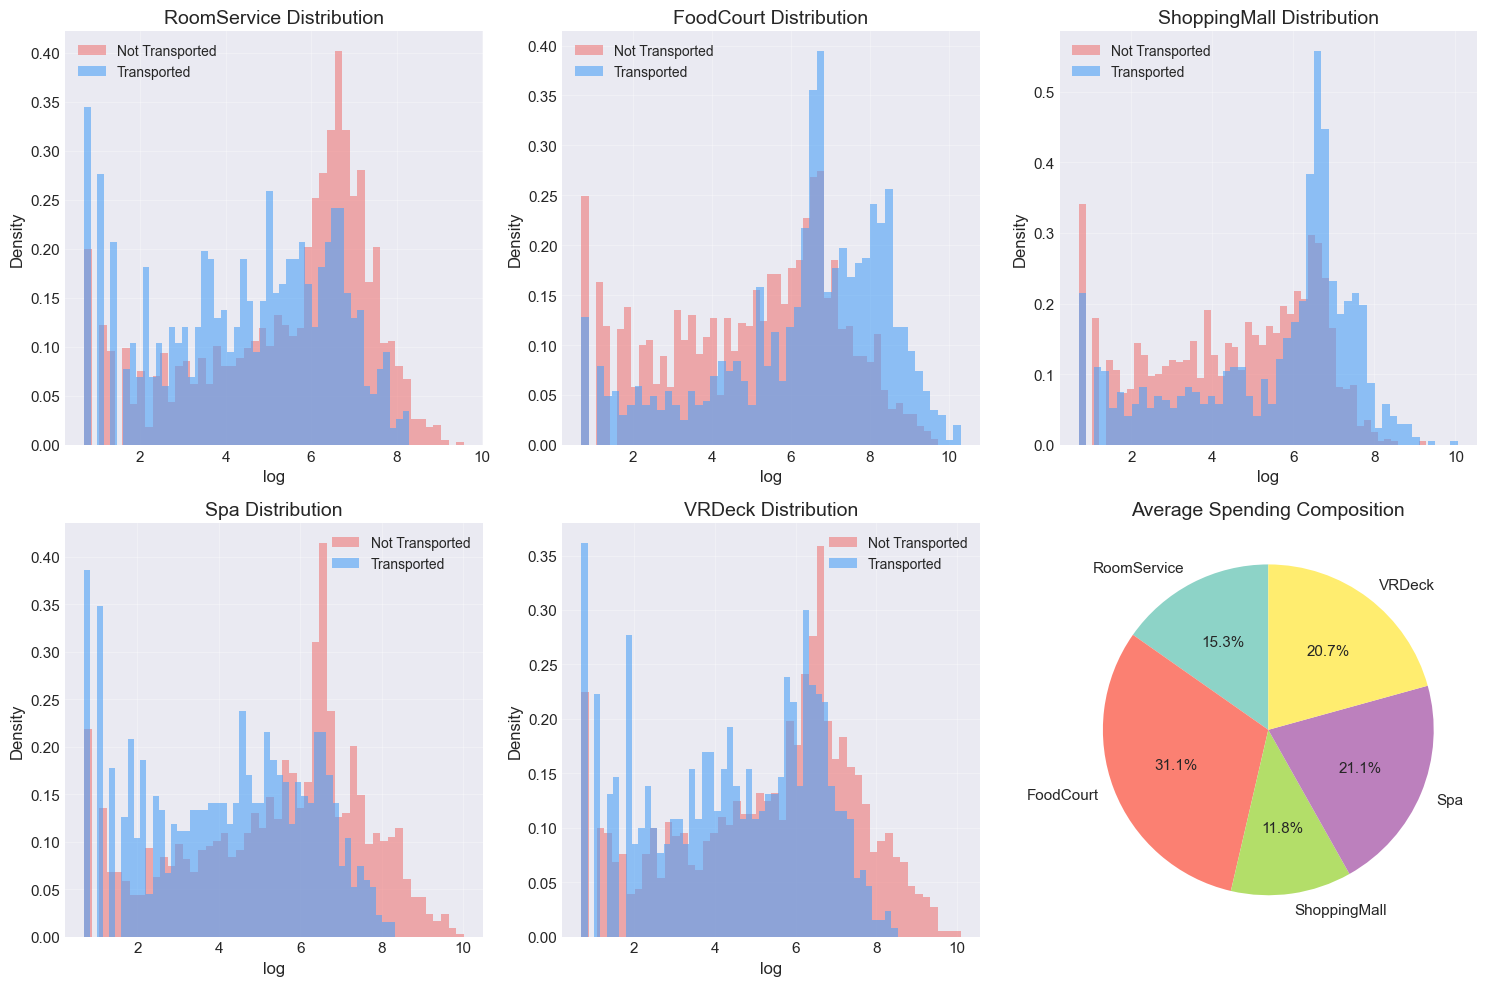

In [190]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, col in enumerate(spend_cols):
    row, col_idx = idx // 3, idx % 3
    for transported, color, label in zip([False, True], ["#EF7979", "#4EA2F6"], ['Not Transported', 'Transported']):
        data = train[train['Transported'] == transported][col]
        data_clean = data[data > 0]
        if len(data_clean) > 0:
            axes[row, col_idx].hist(np.log1p(data_clean), bins=50, alpha=0.6, color=color, label=label, density=True)
    axes[row, col_idx].set_title(f'{col} Distribution')
    axes[row, col_idx].set_xlabel('log')
    axes[row, col_idx].set_ylabel('Density')
    axes[row, col_idx].legend()
    axes[row, col_idx].grid(alpha=0.3)

avg_spending = train[spend_cols].mean()
axes[1, 2].pie(avg_spending.values, labels=avg_spending.index, autopct='%1.1f%%',
               colors=plt.cm.Set3(np.linspace(0, 1, 5)), startangle=90)
axes[1, 2].set_title('Average Spending Composition')

plt.tight_layout()
plt.show()

Outlier detection

C:\Users\admin\AppData\Local\Temp\ipykernel_19292\1552527131.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_violin, x='Type', y='TotalSpending', ax=axes[0], inner='quartile', palette=['#4EA2F6'])
C:\Users\admin\AppData\Local\Temp\ipykernel_19292\1552527131.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_violin2, x='Transported', y='TotalSpending', ax=axes[1], inner='quartile', palette=["#EF7979", '#4EA2F6'])


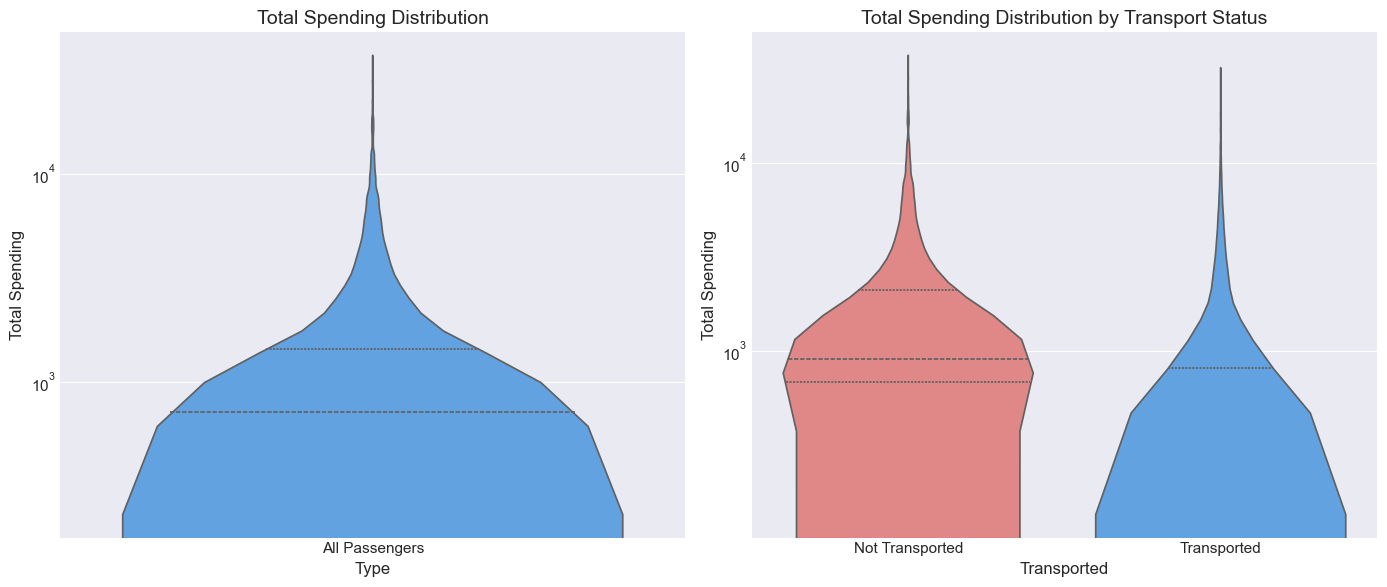

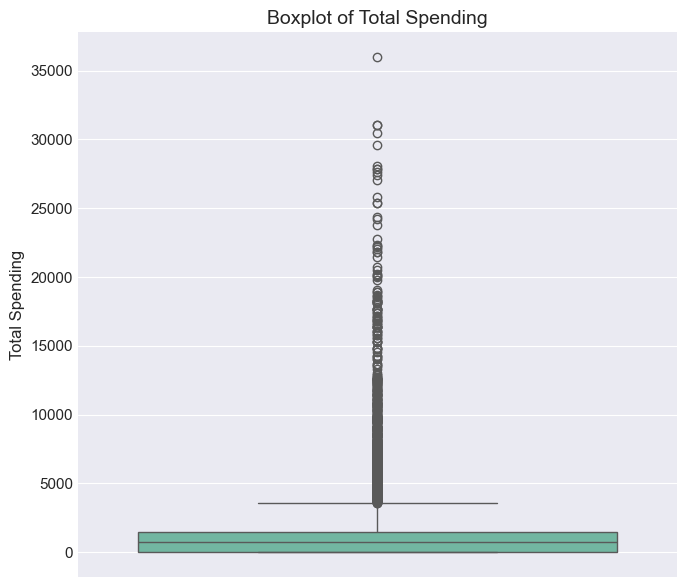

In [191]:
spending_sum = train[['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']].sum(axis=1)

spending_not_transported = spending_sum[train['Transported'] == False]
spending_transported = spending_sum[train['Transported'] == True]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

spending_sum = train[['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']].sum(axis=1)
df_violin = pd.DataFrame({'TotalSpending': spending_sum, 'Type': 'All Passengers'})
sns.violinplot(data=df_violin, x='Type', y='TotalSpending', ax=axes[0], inner='quartile', palette=['#4EA2F6'])
axes[0].set_yscale('log')
axes[0].set_title('Total Spending Distribution')
axes[0].set_ylabel('Total Spending')

df_violin2 = pd.DataFrame({
    'TotalSpending': np.concatenate([spending_not_transported, spending_transported]),
    'Transported': ['Not Transported']*len(spending_not_transported) + ['Transported']*len(spending_transported)
})
sns.violinplot(data=df_violin2, x='Transported', y='TotalSpending', ax=axes[1], inner='quartile', palette=["#EF7979", '#4EA2F6'])
axes[1].set_yscale('log')
axes[1].set_title('Total Spending Distribution by Transport Status')
axes[1].set_ylabel('Total Spending')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize = (7, 6))
sns.boxplot(y=spending_sum, ax = ax)
ax.set_title('Boxplot of Total Spending')
ax.set_ylabel('Total Spending')
plt.tight_layout()
plt.show()

Feature engineering and data cleaning

In [192]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    split_id = df["PassengerId"].astype(str).str.split("_", expand=True)
    df["GroupId"] = split_id[0]
    df["PassengerNo"] = pd.to_numeric(split_id[1], errors="coerce")

    cabin_split = df["Cabin"].astype(str).replace("nan", np.nan).str.split("/", expand=True)
    df["CabinDeck"] = cabin_split[0]
    df["CabinNum"] = pd.to_numeric(cabin_split[1], errors="coerce")
    df["CabinSide"] = cabin_split[2]

    df["Surname"] = df["Name"].astype(str).str.split().str[-1]
    df.loc[df["Name"].isna(), "Surname"] = np.nan
    df["NameLength"] = df["Name"].astype(str).str.len()

    spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
    for col in spend_cols:
        if col not in df.columns:
            df[col] = np.nan

    df["TotalSpend"] = df[spend_cols].sum(axis=1, skipna=True)
    df["NoSpend"] = (df["TotalSpend"].fillna(0) == 0).astype(int)
    df["LuxurySpend"] = df[["FoodCourt", "ShoppingMall", "Spa", "VRDeck"]].sum(axis=1, skipna=True)
    df["BasicSpend"] = df["RoomService"].fillna(0)
    df["LuxuryRatio"] = df["LuxurySpend"] / (df["TotalSpend"] + 1)

    for col in spend_cols + ["TotalSpend", "LuxurySpend", "BasicSpend"]:
        df[f"Log_{col}"] = np.log1p(df[col].fillna(0))

    df["AgeBin"] = pd.cut(
        df["Age"],
        bins=[-1, 12, 18, 30, 45, 60, 120],
        labels=["child", "teen", "young", "adult", "middle", "senior"],
    ).astype("object")
    df["IsChild"] = (df["Age"].fillna(-1) < 13).astype(int)
    df["IsSenior"] = (df["Age"].fillna(-1) >= 60).astype(int)

    cryo_true = df["CryoSleep"].astype(str).str.lower().eq("true")
    df["CryoAndSpend"] = (cryo_true & (df["TotalSpend"].fillna(0) > 0)).astype(int)
    df["CryoAndNoSpend"] = (cryo_true & (df["TotalSpend"].fillna(0) == 0)).astype(int)

    return df

def add_count_features(train_df: pd.DataFrame, test_df: pd.DataFrame):
    train_df = train_df.copy()
    test_df = test_df.copy()
    train_df["__is_train__"] = 1
    test_df["__is_train__"] = 0
    combined = pd.concat([train_df, test_df], axis=0, ignore_index=True)
    
    if "GroupId" in combined.columns:
        combined["GroupSize"] = combined.groupby("GroupId")["PassengerId"].transform("count")
        combined["IsSolo"] = (combined["GroupSize"] == 1).astype(int)
    else:
        combined["GroupSize"] = 1
        combined["IsSolo"] = 1
    
    if "Surname" in combined.columns:
        combined["SurnameSize"] = combined.groupby("Surname")["PassengerId"].transform("count")
    else:
        combined["SurnameSize"] = 1
    
    train_new = combined[combined["__is_train__"] == 1].drop(columns=["__is_train__"])
    test_new = combined[combined["__is_train__"] == 0].drop(columns=["__is_train__"])
    return train_new.reset_index(drop=True), test_new.reset_index(drop=True)

def prepare_data(train_df, test_df):
    if "Transported" not in train_df.columns:
        raise ValueError("Training file must contain target column: Transported")

    y = train_df["Transported"].astype(bool).astype(int)
    test_ids = test_df["PassengerId"].copy()

    train_features = train_df.drop(columns=["Transported"])
    train_features = add_features(train_features)
    test_features = add_features(test_df)
    train_features, test_features = add_count_features(train_features, test_features)

    drop_cols = ["PassengerId", "Name", "Cabin"]
    train_features = train_features.drop(columns=[c for c in drop_cols if c in train_features.columns])
    test_features = test_features.drop(columns=[c for c in drop_cols if c in test_features.columns])

    return train_features, y, test_features, test_ids

X, y, test, test_ids = prepare_data(train, test)
test_original = test.copy()

Get columns type

In [193]:
def get_feature_columns(X: pd.DataFrame):
    from pandas.api.types import (
        is_bool_dtype,
        is_categorical_dtype,
        is_numeric_dtype,
        is_object_dtype,
        is_string_dtype,
    )
    
    numeric_cols = []
    categorical_cols = []
    for col in X.columns:
        s = X[col]
        if is_object_dtype(s) or is_string_dtype(s) or is_categorical_dtype(s) or is_bool_dtype(s):
            categorical_cols.append(col)
        elif is_numeric_dtype(s):
            numeric_cols.append(col)
        else:
            categorical_cols.append(col)
    return numeric_cols, categorical_cols

Data preprocessing

In [194]:
def ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", min_frequency=5, sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def make_preprocessor(numeric_cols, categorical_cols):
    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
    ])
    
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("to_string", FunctionTransformer(lambda x: x.astype(str), validate=False)),
        ("onehot", ohe()),
    ])
    
    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, numeric_cols),
            ("cat", categorical_pipe, categorical_cols),
        ],
        remainder="drop",
    )

numeric_cols, categorical_cols = get_feature_columns(X)

preprocessor = make_preprocessor(numeric_cols, categorical_cols)

X_cv = X.copy()
X = preprocessor.fit_transform(X)
test = preprocessor.transform(test)

C:\Users\admin\AppData\Local\Temp\ipykernel_19292\140012137.py:14: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if is_object_dtype(s) or is_string_dtype(s) or is_categorical_dtype(s) or is_bool_dtype(s):


Train-test split

In [195]:
X_train, X_val, y_train, y_val, train_indices, val_indices = train_test_split(
    X, y, np.arange(len(X)), 
    test_size=0.2, 
    random_state=RANDOM_STATE, 
    stratify=y
)

Base models

In [196]:
base_models = {
    'Logistic Regression': LogisticRegression(
        max_iter = 1000,
        random_state = RANDOM_STATE),
    'SVM': SVC(
        random_state = RANDOM_STATE,
        probability = True),
    'Random Forest': RandomForestClassifier(
        n_estimators = 100,
        random_state = RANDOM_STATE,
        n_jobs = -1),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators = 100,
        random_state = RANDOM_STATE),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators = 100,
        random_state = RANDOM_STATE,
        n_jobs = -1),
}

Advanced models

In [197]:
advanced_models = {
    "XGBoost": XGBClassifier(
        n_estimators=500,
        max_depth=3,
        learning_rate=0.025,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=2,
        gamma=0.02,
        reg_lambda=2.5,
        reg_alpha=0.08,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=650,
        learning_rate=0.022,
        num_leaves=24,
        max_depth=-1,
        min_child_samples=35,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=2.0,
        reg_alpha=0.08,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    ),
    "CatBoost": CatBoostClassifier(
        iterations=650,
        depth=5,
        learning_rate=0.025,
        l2_leaf_reg=5.0,
        random_strength=0.8,
        bagging_temperature=0.6,
        loss_function="Logloss",
        eval_metric="Accuracy",
        random_seed=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
    )
}

Base model training and evaluation

In [198]:
performance_results = {}
trained_models = {}

for name, model in base_models.items():
    y_pred_proba = cross_val_predict(model, X, y, cv=N_SPLITS, method='predict_proba', n_jobs=-1)[:, 1]
    y_pred = (y_pred_proba >= 0.5).astype(int)
    
    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, zero_division=0)
    rec = recall_score(y, y_pred, zero_division=0)
    f1 = f1_score(y, y_pred, zero_division=0)
    auc = roc_auc_score(y, y_pred_proba)
    
    performance_results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc
    }

    print(f"{name}: Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    
    model.fit(X, y)
    trained_models[name] = model

Logistic Regression: Accuracy: 0.7871 | Precision: 0.7684 | Recall: 0.8262 | F1: 0.7963
SVM: Accuracy: 0.7878 | Precision: 0.7531 | Recall: 0.8607 | F1: 0.8033
Random Forest: Accuracy: 0.7960 | Precision: 0.8035 | Recall: 0.7876 | F1: 0.7955
Gradient Boosting: Accuracy: 0.7906 | Precision: 0.8034 | Recall: 0.7736 | F1: 0.7882
Extra Trees: Accuracy: 0.7875 | Precision: 0.8077 | Recall: 0.7588 | F1: 0.7825


Make catboost frame

In [199]:
def make_catboost_frame(X: pd.DataFrame, numeric_cols, categorical_cols):
    Xc = X.copy()
    for col in numeric_cols:
        Xc[col] = pd.to_numeric(Xc[col], errors="coerce")
        Xc[col] = Xc[col].fillna(Xc[col].median())
    for col in categorical_cols:
        Xc[col] = Xc[col].astype("object").where(Xc[col].notna(), "Missing").astype(str)
    return Xc

Advanced model training and evaluation

In [200]:
def train_advanced_predictions(X: pd.DataFrame, y: pd.Series) -> pd.DataFrame:
    results = {}
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    val_probs_dict: Dict[str, np.ndarray] = {name: np.zeros(len(X)) for name in advanced_models.keys()}
    
    for name, advanced_model in advanced_models.items():
        fold_scores = []

        for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), start=1):
            X_tr = X.iloc[tr_idx]
            X_val_fold = X.iloc[val_idx]
            y_tr = y.iloc[tr_idx]
            y_val_fold = y.iloc[val_idx]
            
            if name == "CatBoost":
                model = clone(advanced_model)
                X_tr_cb = make_catboost_frame(X_tr, numeric_cols, categorical_cols)
                X_val_cb = make_catboost_frame(X_val_fold, numeric_cols, categorical_cols)
                cat_feature_indices = [X_tr_cb.columns.get_loc(c) for c in categorical_cols]
                model.fit(X_tr_cb, y_tr, cat_features=cat_feature_indices, verbose=False)
                val_prob = model.predict_proba(X_val_cb)[:, 1]
            else:
                model = clone(advanced_model)
                X_tr_enc = preprocessor.fit_transform(X_tr)
                X_val_enc = preprocessor.transform(X_val_fold)
                model.fit(X_tr_enc, y_tr)
                val_prob = model.predict_proba(X_val_enc)[:, 1]
            
            trained_models[name] = model
            val_probs_dict[name][val_idx] = val_prob
            val_pred = (val_prob >= 0.5).astype(int)
            fold_acc = accuracy_score(y_val_fold, val_pred)
            fold_scores.append(fold_acc)

        y_val_pred = (val_probs_dict[name] >= 0.5).astype(int)
        acc = accuracy_score(y, y_val_pred)
        prec = precision_score(y, y_val_pred, zero_division=0)
        rec = recall_score(y, y_val_pred, zero_division=0)
        f1 = f1_score(y, y_val_pred, zero_division=0)
        auc = roc_auc_score(y, val_probs_dict[name])
        
        results[name] = {
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1-Score': f1,
            'ROC-AUC': auc,
        }
        
        print(f"{name}: Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
        
        performance_results[name] = results[name]

train_advanced_predictions(X_cv, y)

XGBoost: Accuracy: 0.8065 | Precision: 0.8020 | Recall: 0.8177 | F1: 0.8098
LightGBM: Accuracy: 0.8109 | Precision: 0.8261 | Recall: 0.7910 | F1: 0.8082
CatBoost: Accuracy: 0.8135 | Precision: 0.8069 | Recall: 0.8278 | F1: 0.8172


Ensemble learning

In [201]:
def percentile_rank(values: np.ndarray) -> np.ndarray:
    return pd.Series(values).rank(method="average", pct=True).values

def blend_base_predictions(base_probs: pd.DataFrame) -> np.ndarray:
    required = ["XGBoost", "LightGBM", "CatBoost"]
    missing = [c for c in required if c not in base_probs.columns]
    if missing:
        raise ValueError(f"Base prediction file is missing columns: {missing}")

    x = base_probs["XGBoost"].values
    l = base_probs["LightGBM"].values
    c = base_probs["CatBoost"].values

    prob_blend = W_XGBOOST * x + W_LIGHTGBM * l + W_CATBOOST * c

    rank_blend = (
        W_XGBOOST * percentile_rank(x)
        + W_LIGHTGBM * percentile_rank(l)
        + W_CATBOOST * percentile_rank(c)
    )

    final_score = ALPHA_PROBABILITY * prob_blend + (1.0 - ALPHA_PROBABILITY) * rank_blend
    return final_score

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
ensemble_cv_probs = np.zeros(len(X_cv))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_cv, y), 1):
    X_tr = X_cv.iloc[train_idx]
    X_val_fold = X_cv.iloc[val_idx]
    y_tr = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]
    X_tr_enc = preprocessor.fit_transform(X_tr)
    
    fold_probs_dict = {}
    
    for name, model in advanced_models.items():
        if name == "CatBoost":
            model_clone = clone(model)
            X_tr_cb = make_catboost_frame(X_tr, numeric_cols, categorical_cols)
            X_val_cb = make_catboost_frame(X_val_fold, numeric_cols, categorical_cols)
            cat_features = [X_tr_cb.columns.get_loc(c) for c in categorical_cols]
            model_clone.fit(X_tr_cb, y_tr, cat_features=cat_features, verbose=False)
            val_probs = model_clone.predict_proba(X_val_cb)[:, 1]
        else:
            model_clone = clone(model)
            X_val_enc = preprocessor.transform(X_val_fold)
            model_clone.fit(X_tr_enc, y_tr)
            val_probs = model_clone.predict_proba(X_val_enc)[:, 1]
        
        fold_probs_dict[name] = val_probs
    
    fold_probs_df = pd.DataFrame(fold_probs_dict)
    fold_ensemble_score = blend_base_predictions(fold_probs_df)
    
    ensemble_cv_probs[val_idx] = fold_ensemble_score

ensemble_cv_pred = (ensemble_cv_probs >= DECISION_THRESHOLD).astype(int)

ensemble_metrics = {
    'Accuracy': accuracy_score(y, ensemble_cv_pred),
    'Precision': precision_score(y, ensemble_cv_pred, zero_division=0),
    'Recall': recall_score(y, ensemble_cv_pred, zero_division=0),
    'F1-Score': f1_score(y, ensemble_cv_pred, zero_division=0),
    'ROC-AUC': roc_auc_score(y, ensemble_cv_probs),
}

print(f"Ensemble: Accuracy: {ensemble_metrics['Accuracy']:.4f} | Precision: {ensemble_metrics['Precision']:.4f} | Recall: {ensemble_metrics['Recall']:.4f} | F1: {ensemble_metrics['F1-Score']:.4f}")

performance_results['Ensemble'] = ensemble_metrics

Ensemble: Accuracy: 0.8124 | Precision: 0.8131 | Recall: 0.8148 | F1: 0.8139


Cross-validation score

In [202]:
for name, model in base_models.items():
    scores = cross_val_score(model, X_train, y_train, cv = 5, scoring='accuracy', n_jobs = -1)
    print(f"{name:25} | Accuracy: {scores.mean():.4f} +/- {scores.std():.4f}")

for name, model in advanced_models.items():
    scores = cross_val_score(model, X_train, y_train, cv = 5, scoring='accuracy', n_jobs = -1)
    print(f"{name:25} | Accuracy: {scores.mean():.4f} +/- {scores.std():.4f}")

Logistic Regression       | Accuracy: 0.7879 +/- 0.0056
SVM                       | Accuracy: 0.7876 +/- 0.0096
Random Forest             | Accuracy: 0.7936 +/- 0.0084
Gradient Boosting         | Accuracy: 0.7982 +/- 0.0097
Extra Trees               | Accuracy: 0.7872 +/- 0.0060
XGBoost                   | Accuracy: 0.8064 +/- 0.0103
LightGBM                  | Accuracy: 0.8059 +/- 0.0080
CatBoost                  | Accuracy: 0.8092 +/- 0.0085


Hyperparameter tuning for Logistic Regression

In [203]:
lr_param_grid = {
    'C': [0.01, 0.1, 1],
    'l1_ratio': [0.0, 1.0],
    'solver': ['liblinear',  'saga']
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter = 1000, random_state = 42),
    lr_param_grid,
    cv = 5,
    scoring = 'accuracy',
    n_jobs = -1
)

lr_grid.fit(X_train, y_train)

trained_models['Logistic Regression'] = lr_grid.best_estimator_

print(f"Best parameters: {lr_grid.best_params_}\n")
print(f"Best cross-validation score: {lr_grid.best_score_}\n")

Best parameters: {'C': 0.1, 'l1_ratio': 0.0, 'solver': 'liblinear'}

Best cross-validation score: 0.7913434256189584



Hyperparameter tuning for SVM

In [204]:
svm_param_grid = {
    'C': [10],
    'gamma': [0.1],
    'kernel': ['rbf']
}

svm_grid = GridSearchCV(
    SVC(random_state = 42),
    svm_param_grid,
    cv = 5,
    scoring = 'accuracy',
    n_jobs = -1
)

svm_grid.fit(X_train, y_train)

trained_models['SVM'] = svm_grid.best_estimator_

print(f"Best parameters: {svm_grid.best_params_}\n")
print(f"Best cross-validation score: {svm_grid.best_score_}\n")

Best parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}

Best cross-validation score: 0.6249647011362873



Hyperparameter tuning for Random Forest

In [205]:
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state = RANDOM_STATE, n_jobs = -1),
    rf_param_grid,
    cv = 5,
    scoring='accuracy',
    n_jobs = -1
)

rf_grid.fit(X_train, y_train)

trained_models['Random Forest'] = rf_grid.best_estimator_

print(f"Best parameters: {rf_grid.best_params_}\n")
print(f"Best cross-validation score: {rf_grid.best_score_:.4f}\n")


Best parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}

Best cross-validation score: 0.7981



Hyperparameter tuning for Gradient Boosting

In [206]:
gb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state = RANDOM_STATE),
    gb_param_grid,
    cv = 5,
    scoring='accuracy',
    n_jobs = -1
)

gb_grid.fit(X_train, y_train)

trained_models['Gradient Boosting'] = gb_grid.best_estimator_

print(f"Best parameters: {gb_grid.best_params_}\n")
print(f"Best cross-validation score: {gb_grid.best_score_:.4f}\n")

Best parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}

Best cross-validation score: 0.8054



Model performance comparison

In [207]:
print("Performance comparison:")
performance = pd.DataFrame(performance_results).T.round(4)
print(performance)

Performance comparison:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.7871     0.7684  0.8262    0.7963   0.8717
SVM                    0.7878     0.7531  0.8607    0.8033   0.8283
Random Forest          0.7960     0.8035  0.7876    0.7955   0.8779
Gradient Boosting      0.7906     0.8034  0.7736    0.7882   0.8840
Extra Trees            0.7875     0.8077  0.7588    0.7825   0.8700
XGBoost                0.8065     0.8020  0.8177    0.8098   0.8985
LightGBM               0.8109     0.8261  0.7910    0.8082   0.9025
CatBoost               0.8135     0.8069  0.8278    0.8172   0.9026
Ensemble               0.8124     0.8131  0.8148    0.8139   0.9041


Feature importance analysis


XGBoost Top 10 feature importance:

          feature  importance
          NoSpend    0.387770
   CryoSleep_True    0.088760
   CryoAndNoSpend    0.086306
 HomePlanet_Earth    0.042887
       TotalSpend    0.033062
  CryoSleep_False    0.025024
      CabinDeck_E    0.018205
      RoomService    0.018010
HomePlanet_Europa    0.017886
     ShoppingMall    0.017283

LightGBM Top 10 feature importance:

     feature  importance
    CabinNum        2079
         Age        1234
      VRDeck        1177
         Spa        1134
   FoodCourt         891
  TotalSpend         823
 SurnameSize         732
ShoppingMall         687
 LuxuryRatio         669
  NameLength         554

CatBoost Top 10 feature importance:

        feature  importance
     BasicSpend    9.817745
    LuxuryRatio    8.136003
    RoomService    7.788731
            Age    7.538954
     NameLength    6.311483
 CryoAndNoSpend    6.003875
     TotalSpend    5.518984
      GroupSize    5.411422
    PassengerNo    4.801390
Lo

C:\Users\admin\AppData\Local\Temp\ipykernel_19292\1890211974.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_features, y='feature', x='importance', palette='viridis')


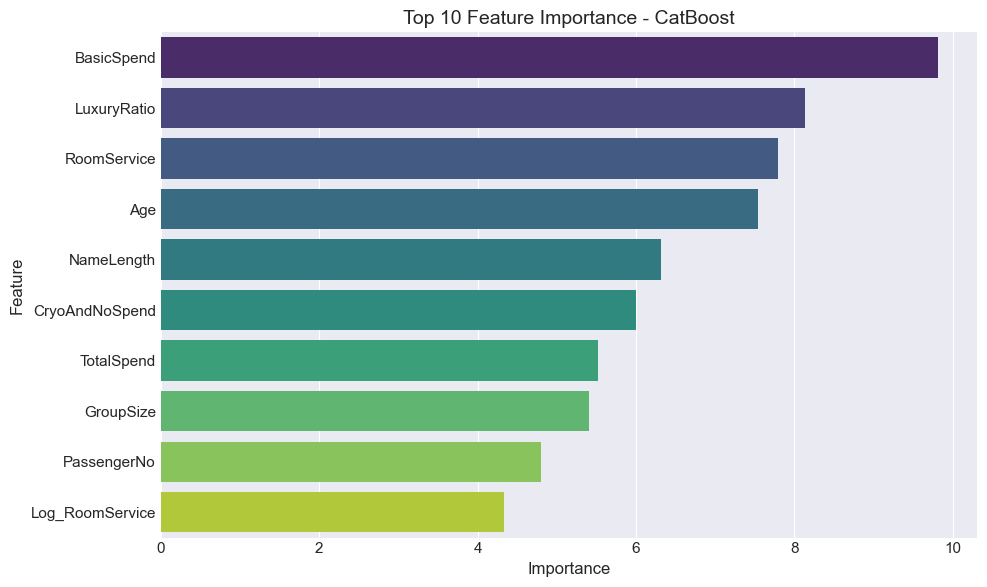

In [208]:
feature_importance_dict = {}

preprocessor_feature_names = (
    preprocessor.named_transformers_['num'].get_feature_names_out(numeric_cols).tolist()
    + preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols).tolist()
)

for name, model in trained_models.items():
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        if len(importances) != len(preprocessor_feature_names):
            if name == "CatBoost" and hasattr(model, "feature_importances_"):
                cat_feature_names = numeric_cols + categorical_cols
                importances = model.feature_importances_
                feature_names_used = cat_feature_names
            else:
                continue
        else:
            feature_names_used = preprocessor_feature_names

        imp_df = pd.DataFrame({
            'feature': feature_names_used[:len(importances)],
            'importance': importances
        }).sort_values('importance', ascending=False).head(15)

        feature_importance_dict[name] = imp_df

        print(f"\n{name} Top 10 feature importance:\n")
        print(imp_df.head(10).to_string(index=False))

best_model_name = performance['Accuracy'].idxmax()
if best_model_name in feature_importance_dict:
    plt.figure(figsize=(10, 6))
    top_features = feature_importance_dict[best_model_name].head(10)
    sns.barplot(data=top_features, y='feature', x='importance', palette='viridis')
    plt.title(f'Top 10 Feature Importance - {best_model_name}')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

Computational cost comparison

In [209]:
computational_results = {}

for name, model in list(trained_models.items()):
    print(f"{name}:\n")
    
    tracemalloc.start()
    gc.collect()
    
    snapshot1 = tracemalloc.take_snapshot()
    
    start_time = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_time
    
    snapshot2 = tracemalloc.take_snapshot()
    
    start_time = time.time()
    for _ in range(10):
        model.predict(test)
    inference_time = (time.time() - start_time) / 100
    
    stat_diff = snapshot2.compare_to(snapshot1, 'lineno')
    mem_allocated = sum(stat.size for stat in stat_diff if stat.size > 0) / 1024 / 1024
    
    tracemalloc.stop()
    
    computational_results[name] = {
        'Training Time (s)': training_time,
        'Inference Time (ms)': inference_time * 1000,
        'Memory Allocated (MB)': mem_allocated
    }
    
    print(f"{name:30} Train: {training_time:.4f}s | Infer: {inference_time*1000:.2f}ms | Memory Alloc: {mem_allocated:.2f}MB\n")

Logistic Regression:

Logistic Regression            Train: 0.2111s | Infer: 1.29ms | Memory Alloc: 0.01MB

SVM:

SVM                            Train: 55.6952s | Infer: 3409.97ms | Memory Alloc: 48.95MB

Random Forest:

Random Forest                  Train: 1.6689s | Infer: 22.58ms | Memory Alloc: 0.40MB

Gradient Boosting:

Gradient Boosting              Train: 78.3971s | Infer: 5.31ms | Memory Alloc: 0.10MB

Extra Trees:

Extra Trees                    Train: 0.6994s | Infer: 12.95ms | Memory Alloc: 0.27MB

XGBoost:

XGBoost                        Train: 2.1268s | Infer: 0.54ms | Memory Alloc: 0.02MB

LightGBM:

LightGBM                       Train: 4.5768s | Infer: 2.49ms | Memory Alloc: 0.04MB

CatBoost:

CatBoost                       Train: 4.6912s | Infer: 1.96ms | Memory Alloc: 0.04MB



C:\Users\admin\AppData\Local\Temp\ipykernel_19292\74963578.py:33: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[1].annotate(name, (train_times[i], accuracies[i]), xytext=(5, 5), textcoords='offset points')


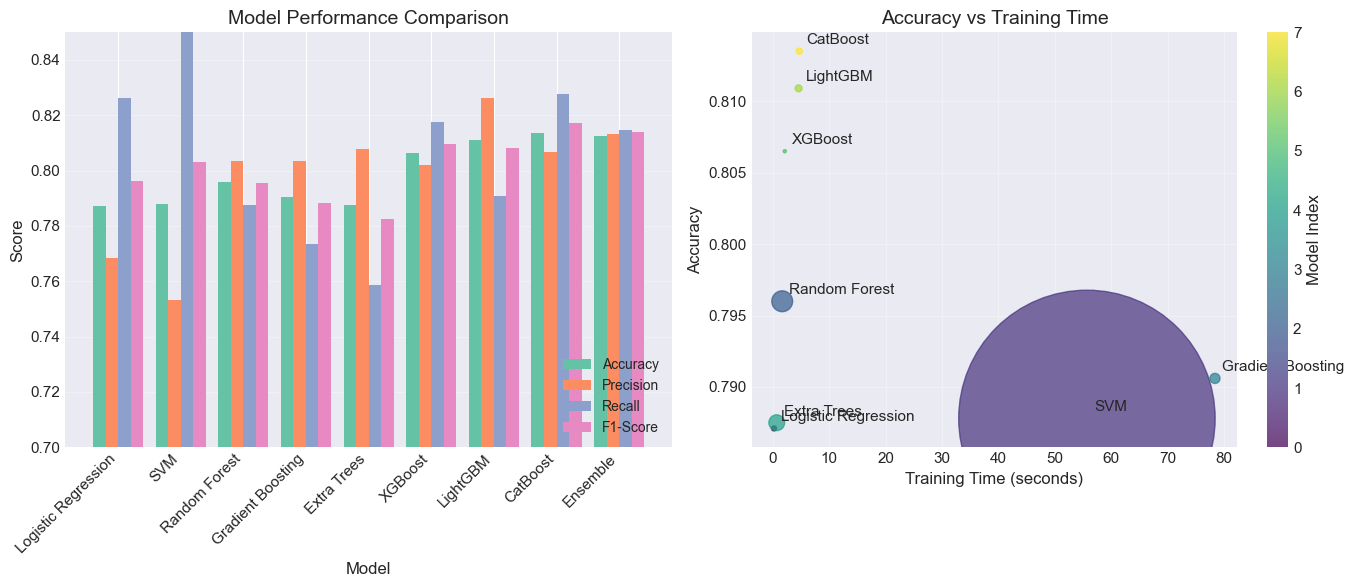

In [210]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(performance))
width = 0.2

for i, metric in enumerate(metrics):
    axes[0].bar(x + i*width, performance[metric], width, label=metric)

axes[0].set_xlabel('Model')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison')
axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(performance.index, rotation=45, ha='right')
axes[0].legend(loc='lower right')
axes[0].set_ylim(0.7, 0.85)
axes[0].grid(axis='y', alpha=0.3)

computational_renamed = {}
for name, value in computational_results.items():
    display_name = name.replace('ensemble_', '')
    computational_renamed[display_name] = value

time_data = pd.DataFrame(computational_renamed).T
model_names = time_data.index
accuracies = [performance.loc[name, 'Accuracy'] for name in model_names]
train_times = time_data['Training Time (s)']
sizes = time_data['Inference Time (ms)'] * 10

scatter = axes[1].scatter(train_times, accuracies, s=sizes, alpha=0.7, c=range(len(model_names)), cmap='viridis')

for i, name in enumerate(model_names):
    axes[1].annotate(name, (train_times[i], accuracies[i]), xytext=(5, 5), textcoords='offset points')

axes[1].set_xlabel('Training Time (seconds)')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy vs Training Time')
axes[1].grid(alpha=0.3)
cbar = plt.colorbar(scatter, ax=axes[1])
cbar.set_label('Model Index')

plt.tight_layout()
plt.show()

Suitability for the dataset

In [211]:
numerical_features = []
categorical_features = []
mixed_features = []

for col in X_cv.columns:
    if X_cv[col].dtype in ['int64', 'float64']:
        if X_cv[col].nunique() < 10 and X_cv[col].nunique() > 2:
            categorical_features.append(col)
        else:
            numerical_features.append(col)
    else:
        categorical_features.append(col)

missing_ratio = X_cv.isnull().sum() / len(X_cv)
high_missing = missing_ratio[missing_ratio > 0.3]

model_characteristics = {
    'Logistic Regression': {
        'assumptions': ['Linear decision boundary', 'Feature independence', 'No multicollinearity'],
        'strengths': ['Interpretability', 'Fast training', 'Low memory', 'Works well with sparse data'],
        'weaknesses': ['Poor with non-linear relationships', 'Sensitive to outliers', 'Requires feature scaling'],
        'best_for': ['High-dimensional sparse data', 'Linearly separable problems', 'When interpretability is key'],
        'dataset_fit_score': 0,
    },
    'SVM': {
        'assumptions': ['Kernel trick for non-linearity', 'Feature scaling required'],
        'strengths': ['Effective in high dimensions', 'Memory efficient', 'Versatile with different kernels'],
        'weaknesses': ['Poor interpretability', 'Sensitive to feature scaling', 'Slow on large datasets', 'Kernel selection is critical'],
        'best_for': ['High-dimensional data', 'Clear margin of separation', 'When kernel can capture patterns'],
        'dataset_fit_score': 0,
    },
    'Random Forest': {
        'assumptions': ['No distributional assumptions', 'Handles non-linearity well'],
        'strengths': ['Handles missing values', 'Feature importance', 'Robust to outliers', 'No scaling needed'],
        'weaknesses': ['Memory intensive', 'Slower prediction', 'Can overfit with small data'],
        'best_for': ['Mixed data types', 'Non-linear relationships', 'When feature importance is needed'],
        'dataset_fit_score': 0,
    },
    'Gradient Boosting': {
        'assumptions': ['Sequential learning', 'Can handle complex patterns'],
        'strengths': ['High accuracy', 'Handles mixed data', 'Feature importance', 'Regularization options'],
        'weaknesses': ['Slower training', 'Sensitive to outliers', 'Many hyperparameters'],
        'best_for': ['Complex patterns', 'When accuracy is priority', 'Medium-sized datasets'],
        'dataset_fit_score': 0,
    },
    'XGBoost': {
        'assumptions': ['Boosted trees', 'Handles missing values internally'],
        'strengths': ['Very high accuracy', 'Built-in regularization', 'Handles missing values', 'Fast training'],
        'weaknesses': ['Complex', 'Memory intensive', 'Many hyperparameters to tune'],
        'best_for': ['Structured/tabular data', 'Kaggle competitions', 'When maximum accuracy is needed'],
        'dataset_fit_score': 0,
    },
    'LightGBM': {
        'assumptions': ['Leaf-wise growth', 'Categorical feature support'],
        'strengths': ['Very fast training', 'Low memory usage', 'Native categorical support', 'High accuracy'],
        'weaknesses': ['Can overfit on small datasets', 'Leaf-wise growth can cause overfitting'],
        'best_for': ['Large datasets', 'Fast training requirements', 'When memory is limited'],
        'dataset_fit_score': 0,
    },
    'CatBoost': {
        'assumptions': ['Symmetric trees', 'Ordered boosting'],
        'strengths': ['Excellent categorical handling', 'No hyperparameter tuning needed', 'Robust'],
        'weaknesses': ['Slower training than LightGBM', 'Memory intensive'],
        'best_for': ['Categorical-heavy datasets', 'When minimal tuning is desired', 'Small to medium datasets'],
        'dataset_fit_score': 0,
    }
}

for model_name in model_characteristics.keys():
    if model_name in performance.index:
        perf = performance.loc[model_name]
        model_characteristics[model_name]['dataset_fit_score'] = perf['Accuracy'] * 100
        print(f"{model_name}:\n")
        print(model_characteristics[model_name])
        
        if model_name == 'Logistic Regression':
            missing_impact = X_cv.isnull().sum().sum() / (X_cv.shape[0] * X_cv.shape[1])
            print(f"Analysis: LIMITED FIT - Logistic Regression assumes linear decision boundaries, but passenger transportation likely involves non-linear relationships. It requires imputation for {X_cv.isnull().sum().sum():,} missing values ({missing_impact:.1%} of data), and also needs one-hot encoding for {len(categorical_features)} categorical features, which increases dimensionality. Sensitive to outliers in spending features.")
            
        elif model_name == 'SVM':
            print(f"Analysis: MODERATE FIT - SVM can capture non-linear patterns via rbf kernels, which is good for this dataset. However, O(n³) complexity is problematic for {X_cv.shape[0]} samples, making training slow. It can not handle missing values ({X_cv.isnull().sum().sum():,}) or categorical features directly, but also requires careful feature scaling and kernel selection. It's better for smaller datasets with clean, numerical features.")
        
        elif model_name == 'Gradient Boosting':
            print(f"Analysis: EXCELLENT FIT - Traditional Gradient Boosting can capture complex non-linear patterns in the data. It works well with {len(categorical_features)} categorical and {len(numerical_features)} numerical features. However, it's slower than XGBoost and LightGBM and requires more careful tuning of learning rate and tree depth.")
        
        elif model_name == 'Random Forest':
            print(f"Analysis: GOOD FIT - Random Forest's bagging approach provides robustness against overfitting. It can not only handle the {len(high_missing)} features with high missing rates well through surrogate splits, but also can work with {len(categorical_features)} categorical features and {len(numerical_features)} numerical features without scaling. Meanwhile, it can provide feature importance to identify key predictors like CryoSleep and spending patterns.")
        
        elif model_name == 'Extra Trees':
            print(f"Analysis: GOOD FIT - Extra Trees adds extra randomness by selecting split points randomly, which often reduces variance compared to Random Forest. It's computationally faster than Random Forest while maintaining good performance on mixed data types, and handle the dataset's {X_cv.shape[0]} samples efficiently with lower risk of overfitting.")
        
        elif model_name == 'XGBoost':
            print(f"Analysis: EXCELLENT FIT - XGBoost's gradient boosting framework excels with mixed data types. The dataset has {len(categorical_features)} categorical features and {len(numerical_features)} numerical features. XGBoost can handle missing values ({X_cv.isnull().sum().sum():,} total) internally, which is crucial for this dataset. Its built-in regularization also prevents overfitting on the {X_cv.shape[0]} training samples.")
        
        elif model_name == 'LightGBM':
            print(f"Analysis: EXCELLENT FIT - LightGBM's leaf-wise tree growth efficiently handles the dataset's structure. With {len(categorical_features)} categorical features, LightGBM's native categorical feature support is a major advantage. It's also important for quick experimentation, Handling the {X_cv.isnull().sum().sum():,} missing values effectively.")
            
        elif model_name == 'CatBoost':
            print(f"Analysis: EXCELLENT FIT - CatBoost's symmetric trees and ordered boosting are ideal for this dataset. It automatically handles {len(categorical_features)} categorical features without preprocessing, saving significant time. The dataset's mixed data types and missing values ({X_cv.isnull().sum().sum():,}) are also managed seamlessly. It's robustness reduces the need for extensive hyperparameter tuning.")
        
        print("")

Logistic Regression:

{'assumptions': ['Linear decision boundary', 'Feature independence', 'No multicollinearity'], 'strengths': ['Interpretability', 'Fast training', 'Low memory', 'Works well with sparse data'], 'weaknesses': ['Poor with non-linear relationships', 'Sensitive to outliers', 'Requires feature scaling'], 'best_for': ['High-dimensional sparse data', 'Linearly separable problems', 'When interpretability is key'], 'dataset_fit_score': np.float64(78.71000000000001)}
Analysis: LIMITED FIT - Logistic Regression assumes linear decision boundaries, but passenger transportation likely involves non-linear relationships. It requires imputation for 3,101 missing values (0.9% of data), and also needs one-hot encoding for 11 categorical features, which increases dimensionality. Sensitive to outliers in spending features.

SVM:

{'assumptions': ['Kernel trick for non-linearity', 'Feature scaling required'], 'strengths': ['Effective in high dimensions', 'Memory efficient', 'Versatile wit

Prediction result

In [212]:
best_model_name = performance['Accuracy'].idxmax()

if (best_model_name == 'Ensemble'):
    test_probs_dict = {}
    
    X_train_full = X_cv
    y_train_full = y
    
    for name in ["xgboost", "lightgbm", "catboost"]:
        if name == "catboost":
            X_full_cb = make_catboost_frame(X_train_full, numeric_cols, categorical_cols)
            X_test_cb = make_catboost_frame(test_original, numeric_cols, categorical_cols)
            cat_features = [X_full_cb.columns.get_loc(c) for c in categorical_cols]
            
            model = clone(advanced_models[name])
            model.fit(X_full_cb, y_train_full, cat_features=cat_features, verbose=False)
            
            test_probs = model.predict_proba(X_test_cb)[:, 1]
            
        else:
            X_full_enc = preprocessor.fit_transform(X_train_full)
            X_test_enc = preprocessor.transform(test_original)
            
            model = clone(advanced_models[name])
            model.fit(X_full_enc, y_train_full)
            
            test_probs = model.predict_proba(X_test_enc)[:, 1]
        
        test_probs_dict[name] = test_probs
    
    test_probs_df = pd.DataFrame(test_probs_dict)
    final_test_score = blend_base_predictions(test_probs_df)
    predictions = (final_test_score >= DECISION_THRESHOLD).astype(int)
    
else:
    best_model = trained_models[best_model_name]

    prediction = best_model.predict(test)

submission = pd.DataFrame({
    'PassengerId': PassengerId,
    'Transported': prediction.astype(bool)
})

submission.to_csv('submission.csv', index = False)